<a href="https://colab.research.google.com/github/tytytytyiew/practice_5_classification/blob/main/practice_5_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

In [4]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер данных:", X.shape)
print("Распределение классов:")
print(y.value_counts())

Размер данных: (569, 30)
Распределение классов:
target
1    357
0    212
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Первые вероятности:")
print(y_proba[:10])

Первые вероятности:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


ROC-AUC: 0.9953703703703703


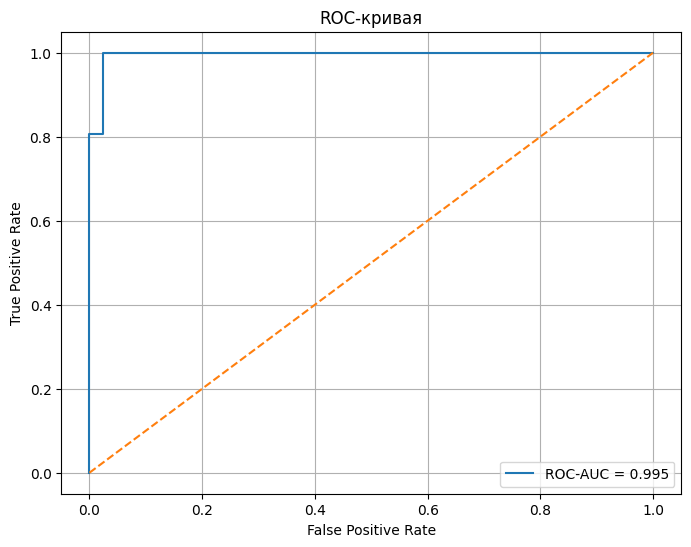

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.grid()
plt.show()

PR-AUC: 0.9970426347413357


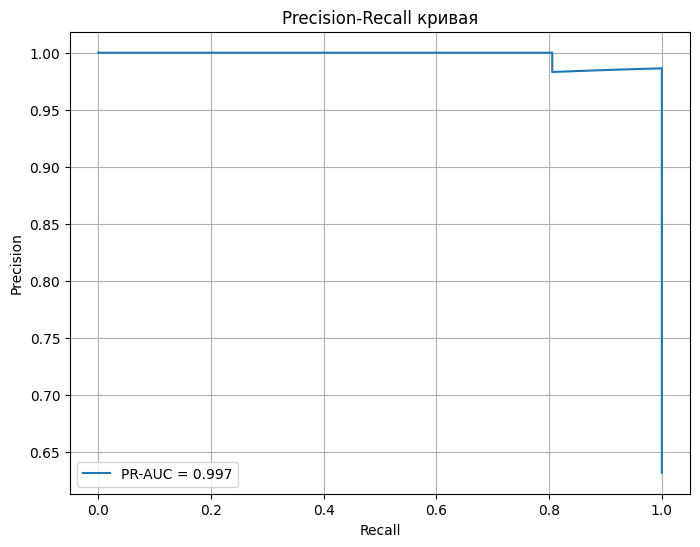

In [8]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_proba
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall кривая")
plt.legend()
plt.grid()
plt.show()

In [9]:
y_pred_default = (y_proba >= 0.5).astype(int)

print("Метрики при пороге 0.5:")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall:", recall_score(y_test, y_pred_default))
print("F1:", f1_score(y_test, y_pred_default))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

Метрики при пороге 0.5:
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1: 0.9861111111111112

Confusion Matrix:
[[41  1]
 [ 1 71]]


In [10]:
thresholds_to_check = np.arange(0.1, 0.91, 0.01)

results = []

for threshold in thresholds_to_check:
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    cost = fp * 1 + fn * 4

    results.append({
        "threshold": threshold,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "cost": cost
    })

results_df = pd.DataFrame(results)

best_result = results_df.loc[
    results_df["cost"].idxmin()
]

best_threshold = best_result["threshold"]

print("Оптимальный порог:", best_threshold)
print(best_result)

Оптимальный порог: 0.3599999999999999
threshold     0.36
FP            1.00
FN            0.00
TP           72.00
TN           41.00
cost          1.00
Name: 26, dtype: float64


In [11]:
y_pred_best = (y_proba >= best_threshold).astype(int)

print("Метрики при оптимальном пороге:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Метрики при оптимальном пороге:
Accuracy: 0.9912280701754386
Precision: 0.9863013698630136
Recall: 1.0
F1: 0.993103448275862

Confusion Matrix:
[[41  1]
 [ 0 72]]


In [12]:
cm_default = confusion_matrix(y_test, y_pred_default)
tn_d, fp_d, fn_d, tp_d = cm_default.ravel()

cm_best = confusion_matrix(y_test, y_pred_best)
tn_b, fp_b, fn_b, tp_b = cm_best.ravel()

cost_default = fp_d * 1 + fn_d * 4
cost_best = fp_b * 1 + fn_b * 4

print("Стоимость ошибок при пороге 0.5:", cost_default)
print("Стоимость ошибок при оптимальном пороге:", cost_best)

Стоимость ошибок при пороге 0.5: 5
Стоимость ошибок при оптимальном пороге: 1
